In [26]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv
from rich import print
from langgraph.checkpoint.memory import InMemorySaver

In [27]:
load_dotenv()

llm = ChatMistralAI(model="mistral-small-2506")

In [28]:
class JokeState(TypedDict):
  topic: str
  joke: str
  explanation: str

In [29]:
def generate_joke(state: JokeState) -> JokeState:
  prompt = f"generate a joke on the topic: {state['topic']}. just give me the joke"
  response = llm.invoke(prompt).content

  return {'joke': response} 

def generate_explanation(state: JokeState) -> JokeState:
  prompt = f"write an explanation for the joke:{state['joke']}. just give me the explanation"
  response = llm.invoke(prompt).content

  return  {'explanation': response}

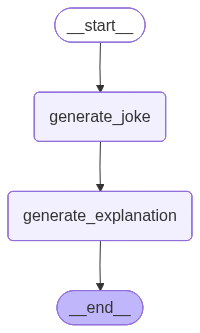

In [30]:
graph = StateGraph(JokeState)


# nodes
graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

# edges
graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

# creating in memory saver checkpointer
checkpointer = InMemorySaver()

# compile the graph with the checkpointer
workflow = graph.compile(checkpointer=checkpointer)

workflow

In [31]:
config1 = {'configurable': {'thread_id': "1"}}
config2 = {'configurable': {'thread_id': "2"}}

initial_state = {
  'topic': 'pizza'
}

final_state = workflow.invoke(initial_state, config=config2)

print(final_state)

{
    'topic': 'pizza',
    'joke': 'Why did the pizza go to school?\n\nBecause it needed to get a little *cheesier*! 🍕😄',
    'explanation': 'The joke plays on the double meaning of the word "cheesier." On one level, it literally means 
the pizza needs more cheese (as in "cheesier" as an adjective for cheese). On another level, "cheesier" can mean 
something is overly sentimental, exaggerated, or corny—like a bad joke or a cheesy movie.\n\nThe humor comes from 
the unexpected twist: instead of the pizza just wanting more cheese, it’s "getting cheesier" in the sense of 
becoming more exaggerated or silly (like a student trying to impress others). The punchline subverts the 
straightforward expectation, making it funny.\n\nIt’s a classic example of a pun—using a word\'s multiple meanings 
for comedic effect. 😊'
}

In [32]:
print(workflow.get_state(config2))

StateSnapshot(
    values={
        'topic': 'pizza',
        'joke': 'Why did the pizza go to school?\n\nBecause it needed to get a little *cheesier*! 🍕😄',
        'explanation': 'The joke plays on the double meaning of the word "cheesier." On one level, it literally 
means the pizza needs more cheese (as in "cheesier" as an adjective for cheese). On another level, "cheesier" can 
mean something is overly sentimental, exaggerated, or corny—like a bad joke or a cheesy movie.\n\nThe humor comes 
from the unexpected twist: instead of the pizza just wanting more cheese, it’s "getting cheesier" in the sense of 
becoming more exaggerated or silly (like a student trying to impress others). The punchline subverts the 
straightforward expectation, making it funny.\n\nIt’s a classic example of a pun—using a word\'s multiple meanings 
for comedic effect. 😊'
    },
    next=(),
    config={
        'configurable': {
            'thread_id': '2',
            'checkpoint_ns': '',
            'checkpoint_id': '1f13998f-8a6c-652e-8002-a7d9415e6e1d'
        }
    },
    metadata={'source': 'loop', 'step': 2, 'parents': {}},
    created_at='2026-04-16T13:34:19.468713+00:00',
    parent_config={
        'configurable': {
            'thread_id': '2',
            'checkpoint_ns': '',
            'checkpoint_id': '1f13998f-6d93-6f24-8001-7361f42fa285'
        }
    },
    tasks=(),
    interrupts=()
)

In [33]:
print(list(workflow.get_state_history(config2)))

[
    StateSnapshot(
        values={
            'topic': 'pizza',
            'joke': 'Why did the pizza go to school?\n\nBecause it needed to get a little *cheesier*! 🍕😄',
            'explanation': 'The joke plays on the double meaning of the word "cheesier." On one level, it literally
means the pizza needs more cheese (as in "cheesier" as an adjective for cheese). On another level, "cheesier" can 
mean something is overly sentimental, exaggerated, or corny—like a bad joke or a cheesy movie.\n\nThe humor comes 
from the unexpected twist: instead of the pizza just wanting more cheese, it’s "getting cheesier" in the sense of 
becoming more exaggerated or silly (like a student trying to impress others). The punchline subverts the 
straightforward expectation, making it funny.\n\nIt’s a classic example of a pun—using a word\'s multiple meanings 
for comedic effect. 😊'
        },
        next=(),
        config={
            'configurable': {
                'thread_id': '2',
                'checkpoint_ns': '',
                'checkpoint_id': '1f13998f-8a6c-652e-8002-a7d9415e6e1d'
            }
        },
        metadata={'source': 'loop', 'step': 2, 'parents': {}},
        created_at='2026-04-16T13:34:19.468713+00:00',
        parent_config={
            'configurable': {
                'thread_id': '2',
                'checkpoint_ns': '',
                'checkpoint_id': '1f13998f-6d93-6f24-8001-7361f42fa285'
            }
        },
        tasks=(),
        interrupts=()
    ),
    StateSnapshot(
        values={
            'topic': 'pizza',
            'joke': 'Why did the pizza go to school?\n\nBecause it needed to get a little *cheesier*! 🍕😄'
        },
        next=('generate_explanation',),
        config={
            'configurable': {
                'thread_id': '2',
                'checkpoint_ns': '',
                'checkpoint_id': '1f13998f-6d93-6f24-8001-7361f42fa285'
            }
        },
        metadata={'source': 'loop', 'step': 1, 'parents': {}},
        created_at='2026-04-16T13:34:16.444070+00:00',
        parent_config={
            'configurable': {
                'thread_id': '2',
                'checkpoint_ns': '',
                'checkpoint_id': '1f13998f-6758-6da2-8000-ee6848e9a368'
            }
        },
        tasks=(
            PregelTask(
                id='b582b656-4d52-1b9a-9402-456ddbfc989d',
                name='generate_explanation',
                path=('__pregel_pull', 'generate_explanation'),
                error=None,
                interrupts=(),
                state=None,
                result={
                    'explanation': 'The joke plays on the double meaning of the word "cheesier." On one level, it 
literally means the pizza needs more cheese (as in "cheesier" as an adjective for cheese). On another level, 
"cheesier" can mean something is overly sentimental, exaggerated, or corny—like a bad joke or a cheesy 
movie.\n\nThe humor comes from the unexpected twist: instead of the pizza just wanting more cheese, it’s "getting 
cheesier" in the sense of becoming more exaggerated or silly (like a student trying to impress others). The 
punchline subverts the straightforward expectation, making it funny.\n\nIt’s a classic example of a pun—using a 
word\'s multiple meanings for comedic effect. 😊'
                }
            ),
        ),
        interrupts=()
    ),
    StateSnapshot(
        values={'topic': 'pizza'},
        next=('generate_joke',),
        config={
            'configurable': {
                'thread_id': '2',
                'checkpoint_ns': '',
                'checkpoint_id': '1f13998f-6758-6da2-8000-ee6848e9a368'
            }
        },
        metadata={'source': 'loop', 'step': 0, 'parents': {}},
        created_at='2026-04-16T13:34:15.790726+00:00',
        parent_config={
            'configurable': {
                'thread_id': '2',
                'checkpoint_ns': '',
                'checkpoint_id': '1f13998f-6757-6367-bfff-